In [1]:
# ── PART 1: INTERACTIVE CHECKLIST ──────────────────────────────────────────
# Run this cell to evaluate whether YOUR task needs fine-tuning.
# Answer each question honestly (True / False).

scenarios = {
    "Output must follow a strict JSON schema every time"         : False,
    "Brand voice must be consistent across 10,000 outputs"      : False,
    "Domain is specialised (medical, legal, code in niche lang)": False,
    "You have ≥ 500 high-quality labelled examples"             : False,
    "P95 latency budget is < 500 ms (long prompts too slow)"    : False,
    "Data is confidential — cannot use external APIs"           : False,
    "Prompting + few-shot still gives 15%+ error rate"          : False,
}

# ── Edit the True/False values above, then re-run ──────────────────────────

yes_count = sum(scenarios.values())
print("=" * 58)
print("  FINE-TUNING DECISION CHECKLIST")
print("=" * 58)
for reason, applies in scenarios.items():
    icon = "✅" if applies else "⬜"
    print(f"  {icon}  {reason}")

print()
print(f"  Score: {yes_count} / {len(scenarios)} criteria met")
print()

if yes_count == 0:
    print("  🟢 Recommendation: START WITH PROMPTING")
    print("     Use few-shot examples and a well-crafted system prompt.")
elif yes_count <= 2:
    print("  🟡 Recommendation: TRY PROMPTING FIRST")
    print("     If results plateau, consider LoRA fine-tuning.")
elif yes_count <= 4:
    print("  🟠 Recommendation: FINE-TUNE WITH LoRA / PEFT")
    print("     Efficient, cost-effective, strong results.")
else:
    print("  🔴 Recommendation: FULL FINE-TUNING OR LoRA")
    print("     Task complexity justifies the compute investment.")
print("=" * 58)


  FINE-TUNING DECISION CHECKLIST
  ⬜  Output must follow a strict JSON schema every time
  ⬜  Brand voice must be consistent across 10,000 outputs
  ⬜  Domain is specialised (medical, legal, code in niche lang)
  ⬜  You have ≥ 500 high-quality labelled examples
  ⬜  P95 latency budget is < 500 ms (long prompts too slow)
  ⬜  Data is confidential — cannot use external APIs
  ⬜  Prompting + few-shot still gives 15%+ error rate

  Score: 0 / 7 criteria met

  🟢 Recommendation: START WITH PROMPTING
     Use few-shot examples and a well-crafted system prompt.


In [3]:
# ── PART 2: COMPUTE COST CALCULATOR ────────────────────────────────────────
# This cell calculates the memory requirements for full fine-tuning
# so you can decide whether your hardware is sufficient.

def compute_cost_analysis(model_name, param_millions, precision='fp16'):
    """
    Estimates GPU memory needed for full fine-tuning.

    Parameters
    ----------
    model_name     : str   — human-readable model name
    param_millions : float — number of parameters in millions
    precision      : str   — 'fp32' (4 bytes/param) or 'fp16' (2 bytes/param)
    """
    bytes_per_param = 4 if precision == 'fp32' else 2

    params = param_millions * 1e6  # convert millions → raw count

    # Memory components (in GB)
    weights_gb   = (params * bytes_per_param) / 1e9
    gradients_gb = weights_gb                          # same size as weights
    adam_m_gb    = weights_gb                          # Adam momentum
    adam_v_gb    = weights_gb                          # Adam variance
    activations  = weights_gb * 0.5                    # rough estimate

    total_gb = weights_gb + gradients_gb + adam_m_gb + adam_v_gb + activations

    return {
        'Model'         : model_name,
        'Params (M)'    : f'{param_millions:,}',
        'Weights (GB)'  : f'{weights_gb:.1f}',
        'Gradients (GB)': f'{gradients_gb:.1f}',
        'Adam States'   : f'{adam_m_gb + adam_v_gb:.1f}',
        'Total Est. (GB)': f'{total_gb:.1f}',
    }

# Common models to compare
models = [
    ('GPT-2 Small',   117,   'fp16'),
    ('GPT-2 XL',     1500,   'fp16'),
    ('LLaMA-2 7B',   7000,   'fp16'),
    ('LLaMA-2 13B', 13000,   'fp16'),
    ('LLaMA-2 70B', 70000,   'fp16'),
]

print("=" * 72)
print(f"  {'Model':<15} {'Params':>9} {'Weights':>10} {'Grads':>8} {'Adam':>8} {'TOTAL':>10}")
print(f"  {'':15} {'(M)':>9} {'(GB)':>10} {'(GB)':>8} {'(GB)':>8} {'(GB)':>10}")
print("-" * 72)

for name, params, prec in models:
    r = compute_cost_analysis(name, params, prec)
    total = float(r['Total Est. (GB)'])
    flag  = ' ⚠️  Multi-GPU needed' if total > 40 else ''
    print(f"  {r['Model']:<15} {r['Params (M)']:>9} {r['Weights (GB)']:>10}"
          f" {r['Gradients (GB)']:>8} {r['Adam States']:>8} {r['Total Est. (GB)']:>10}{flag}")

print("=" * 72)
print()
print("Precision: fp16 (2 bytes/param). fp32 doubles all values above.")
print("Activations estimated at 0.5× weight size (varies with batch size).")
print()
print("Common available GPU RAM:")
print("  RTX 3090 / 4090 : 24 GB    →  fits GPT-2 XL comfortably")
print("  A100 40 GB       : 40 GB    →  fits LLaMA-2 7B (tight)")
print("  A100 80 GB       : 80 GB    →  fits LLaMA-2 13B comfortably")
print("  4× A100 80 GB    : 320 GB   →  needed for LLaMA-2 70B")


  Model              Params    Weights    Grads     Adam      TOTAL
                        (M)       (GB)     (GB)     (GB)       (GB)
------------------------------------------------------------------------
  GPT-2 Small           117        0.2      0.2      0.5        1.1
  GPT-2 XL            1,500        3.0      3.0      6.0       13.5
  LLaMA-2 7B          7,000       14.0     14.0     28.0       63.0 ⚠️  Multi-GPU needed
  LLaMA-2 13B        13,000       26.0     26.0     52.0      117.0 ⚠️  Multi-GPU needed
  LLaMA-2 70B        70,000      140.0    140.0    280.0      630.0 ⚠️  Multi-GPU needed

Precision: fp16 (2 bytes/param). fp32 doubles all values above.
Activations estimated at 0.5× weight size (varies with batch size).

Common available GPU RAM:
  RTX 3090 / 4090 : 24 GB    →  fits GPT-2 XL comfortably
  A100 40 GB       : 40 GB    →  fits LLaMA-2 7B (tight)
  A100 80 GB       : 80 GB    →  fits LLaMA-2 13B comfortably
  4× A100 80 GB    : 320 GB   →  needed for LLaMA-2

In [4]:
# ── PART 4: LoRA PARAMETER COUNT VISUALISER ─────────────────────────────────
# This cell helps you understand how rank r affects the number of parameters
# and the compression ratio you achieve.

import numpy as np

def lora_param_analysis(d_model, n_heads, n_layers, r_values, target='qv'):
    """
    Calculates LoRA parameter counts for different rank values.

    d_model  : hidden dimension of the model (e.g. 4096 for LLaMA-2 7B)
    n_heads  : number of attention heads (e.g. 32)
    n_layers : number of transformer blocks (e.g. 32)
    r_values : list of rank values to compare
    target   : which matrices to apply LoRA to ('qv' or 'qkvo')
    """
    # Each attention matrix is d_model × d_model
    d = d_model
    k = d_model

    # Number of matrices per layer
    n_matrices = 2 if target == 'qv' else 4   # Q+V or Q+K+V+O

    full_delta_params = d * k * n_matrices * n_layers

    results = []
    for r in r_values:
        lora_params = r * (d + k) * n_matrices * n_layers
        ratio       = full_delta_params / lora_params
        results.append((r, lora_params, ratio))

    return full_delta_params, results

# LLaMA-2 7B architecture
d_model  = 4096
n_heads  = 32
n_layers = 32
r_values = [1, 2, 4, 8, 16, 32, 64]

full_delta, rows = lora_param_analysis(d_model, n_heads, n_layers, r_values)

print("=" * 62)
print("  LoRA RANK COMPARISON — LLaMA-2 7B (Q + V matrices only)")
print(f"  d_model={d_model}, layers={n_layers}")
print("=" * 62)
print(f"  Full ΔW (all layers, Q+V) : {full_delta/1e6:.1f}M parameters")
print()
print(f"  {'Rank r':>8}  {'LoRA Params':>14}  {'Compression':>12}  {'Visual'}")
print("-" * 62)

for r, lora_p, ratio in rows:
    bar_len = max(1, int(40 / ratio))         # bar shrinks as compression grows
    bar     = '█' * bar_len + '░' * (40 - bar_len)
    print(f"  r = {r:>3}    {lora_p/1e6:>10.2f}M    {ratio:>8.0f}× smaller  {bar}")

print("=" * 62)
print()
print("Practical guidance:")
print("  r=4  : summarisation, sentiment, simple classification")
print("  r=8  : instruction following, Q&A  ← most common default")
print("  r=16 : code generation, reasoning tasks")
print("  r=32+: complex multi-step tasks, creative writing")


  LoRA RANK COMPARISON — LLaMA-2 7B (Q + V matrices only)
  d_model=4096, layers=32
  Full ΔW (all layers, Q+V) : 1073.7M parameters

    Rank r     LoRA Params   Compression  Visual
--------------------------------------------------------------
  r =   1          0.52M        2048× smaller  █░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
  r =   2          1.05M        1024× smaller  █░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
  r =   4          2.10M         512× smaller  █░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
  r =   8          4.19M         256× smaller  █░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
  r =  16          8.39M         128× smaller  █░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
  r =  32         16.78M          64× smaller  █░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
  r =  64         33.55M          32× smaller  █░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░

Practical guidance:
  r=4  : summarisation, sentiment, simple classification
  r=8  : instruction following, Q&A  ← most common default
 

In [5]:
# ── PART 4: LoRA FORWARD PASS — STEP BY STEP ──────────────────────────────
# This cell simulates exactly what happens inside one LoRA-augmented layer.
# Uses tiny matrices so you can see every number.

import numpy as np
np.random.seed(42)

print("=" * 55)
print("  LoRA FORWARD PASS — STEP-BY-STEP SIMULATION")
print("=" * 55)

# ── Setup: tiny dimensions for illustration ────────────────────────────────
d_in  = 6    # input dimension
d_out = 6    # output dimension
r     = 2    # LoRA rank
alpha = 4    # scaling factor
scale = alpha / r   # = 2.0

print(f"""
  Dimensions: d_in={d_in}, d_out={d_out}, rank r={r}""")
print(f"  Alpha={alpha}, scale (α/r) = {scale}")

# ── Pre-trained frozen weight matrix W ────────────────────────────────────
W = np.random.randn(d_out, d_in) * 0.5
print(f"""
  W (pre-trained, FROZEN) shape: {W.shape}""")

# ── LoRA adapter matrices ──────────────────────────────────────────────────
# A is initialised with small random values (Gaussian)
# B is initialised to ZERO — so the adapter starts as a no-op
A = np.random.randn(r, d_in) * 0.02    # shape: (r, d_in)
B = np.zeros((d_out, r))               # shape: (d_out, r)  — starts at zero!

print(f"  A (trainable)   shape: {A.shape}  — initialised randomly")
print(f"  B (trainable)   shape: {B.shape}  — initialised to ZERO")
print("  → At initialisation, B@A = 0, so the adapter adds NOTHING.")
print("     Training gradually moves B away from zero.")

# ── Input ──────────────────────────────────────────────────────────────────
x = np.random.randn(d_in)
print(f"""
  Input x shape: {x.shape}""")

# ── STEP 1: Original (frozen) path ────────────────────────────────────────
original_out = W @ x
print(f"""
  STEP 1 — Frozen path:  W @ x""")
print(f"           shape: {W.shape} @ {x.shape} = {original_out.shape}")

# ── STEP 2: LoRA path ─────────────────────────────────────────────────────
# First project DOWN to rank r (through A), then project UP (through B)
low_rank     = A @ x           # (r,d) @ (d,) → (r,)  — COMPRESS
lora_out     = B @ low_rank    # (d,r) @ (r,) → (d,)  — EXPAND
scaled_lora  = scale * lora_out

print(f"""
  STEP 2 — LoRA path:    (α/r) × B @ A @ x""")
print(f"           A @ x   : {A.shape} @ {x.shape} → {low_rank.shape}  (compress to rank)")
print(f"           B @ ^   : {B.shape} @ {low_rank.shape} → {lora_out.shape}  (expand back)")
print(f"           scale × ^: multiply by {scale}")

# ── STEP 3: Merge outputs ──────────────────────────────────────────────────
final_out = original_out + scaled_lora
print(f"""
  STEP 3 — Merge:  original_out + scaled_lora_out""")
print(f"           W @ x        = {original_out[:3].round(3)} ...")
print(f"           (α/r)×B@A@x = {scaled_lora[:3].round(3)} ...  (≈0 at init)")
print(f"           Final output = {final_out[:3].round(3)} ...")

print()
print("  Key insight: At initialisation B=0, so the model behaves")
print("  IDENTICALLY to the original. Training only fine-tunes A and B.")
print("  The frozen W is NEVER modified — catastrophic forgetting avoided.")

  LoRA FORWARD PASS — STEP-BY-STEP SIMULATION

  Dimensions: d_in=6, d_out=6, rank r=2
  Alpha=4, scale (α/r) = 2.0

  W (pre-trained, FROZEN) shape: (6, 6)
  A (trainable)   shape: (2, 6)  — initialised randomly
  B (trainable)   shape: (6, 2)  — initialised to ZERO
  → At initialisation, B@A = 0, so the adapter adds NOTHING.
     Training gradually moves B away from zero.

  Input x shape: (6,)

  STEP 1 — Frozen path:  W @ x
           shape: (6, 6) @ (6,) = (6,)

  STEP 2 — LoRA path:    (α/r) × B @ A @ x
           A @ x   : (2, 6) @ (6,) → (2,)  (compress to rank)
           B @ ^   : (6, 2) @ (2,) → (6,)  (expand back)
           scale × ^: multiply by 2.0

  STEP 3 — Merge:  original_out + scaled_lora_out
           W @ x        = [ 0.027 -0.571  1.996] ...
           (α/r)×B@A@x = [0. 0. 0.] ...  (≈0 at init)
           Final output = [ 0.027 -0.571  1.996] ...

  Key insight: At initialisation B=0, so the model behaves
  IDENTICALLY to the original. Training only fine-tunes A

In [ ]:
import subprocess, sys

packages = [
    'transformers>=4.40.0',
    'datasets>=2.18.0',
    'peft>=0.10.0',
    'accelerate>=0.28.0',
    'evaluate',
    'torch',
    'torchao>=0.16.0',
]

print("Installing required packages...")
for pkg in packages:
    result = subprocess.run(
        [sys.executable, '-m', 'pip', 'install', pkg, '-q'],
        capture_output=True, text=True
    )
    status = '✅' if result.returncode == 0 else '❌'
    print(f"  {status}  {pkg.split('>=')[0]}")

print()
print("All packages ready. Now import them:")

Installing required packages...
  ✅  transformers
  ✅  datasets
  ✅  peft
  ✅  accelerate
  ✅  evaluate


In [ ]:
import torch
import warnings
warnings.filterwarnings('ignore')

from transformers import (
    AutoTokenizer,           # loads the right tokeniser for any model
    AutoModelForSeq2SeqLM,   # loads sequence-to-sequence models (T5, BART...)
    DataCollatorForSeq2Seq,  # pads batches to the same length automatically
    Seq2SeqTrainer,          # Trainer variant for seq2seq tasks
    Seq2SeqTrainingArguments,# TrainingArguments with seq2seq-specific options
    set_seed,                # fixes all random seeds for reproducibility
)
from datasets import Dataset
from peft import (
    LoraConfig,              # defines all LoRA hyperparameters
    get_peft_model,          # wraps any model with LoRA adapters
    TaskType,                # tells PEFT what kind of task we're doing
)
import numpy as np

# ── Choose device ────────────────────────────────────────────────────────────
# 'cuda' = NVIDIA GPU, 'mps' = Apple Silicon, 'cpu' = fallback
DEVICE = 'cuda' if torch.cuda.is_available() else          'mps'  if torch.backends.mps.is_available() else 'cpu'

set_seed(42)   # reproducibility

print(f"✅ All imports successful")
print(f"   Running on device : {DEVICE}")
print(f"   PyTorch version   : {torch.__version__}")
if DEVICE == 'cpu':
    print()
    print("   ℹ️  No GPU detected. The training demo uses a tiny model")
    print("      and tiny dataset — it will still complete on CPU in ~1 minute.")


In [ ]:
# ── PART 5: CREATE A TOY DATASET ────────────────────────────────────────────
# We create a tiny text-summarisation dataset from scratch.
# Task: given a short paragraph, produce a one-sentence summary.
# (In a real project you would load a dataset from Hugging Face Hub.)

# ── Raw data ─────────────────────────────────────────────────────────────────
raw_data = [
    {
        "text": (
            "The water cycle describes the continuous movement of water on Earth. "
            "Water evaporates from oceans and lakes, rises into the atmosphere, "
            "forms clouds, and eventually falls as precipitation. "
            "This cycle is essential for distributing fresh water across the planet."
        ),
        "summary": "The water cycle moves water through evaporation, cloud formation, and precipitation."
    },
    {
        "text": (
            "Photosynthesis is the process by which green plants convert sunlight into food. "
            "Chlorophyll in plant cells absorbs light energy, which is used to combine "
            "carbon dioxide and water into glucose. Oxygen is released as a by-product."
        ),
        "summary": "Plants use sunlight, CO2, and water to produce glucose through photosynthesis."
    },
    {
        "text": (
            "The Internet is a global network of computers connected through standardised protocols. "
            "It enables the sharing of information, communication, and commerce across the world. "
            "The World Wide Web is a service built on top of the Internet."
        ),
        "summary": "The Internet connects computers worldwide, enabling communication and information sharing."
    },
    {
        "text": (
            "Antibiotics are medicines that kill or inhibit the growth of bacteria. "
            "They were first discovered by Alexander Fleming in 1928. "
            "Overuse of antibiotics has led to the rise of drug-resistant bacteria, "
            "which is a major public health concern."
        ),
        "summary": "Antibiotics fight bacteria but overuse has caused dangerous drug resistance."
    },
    {
        "text": (
            "Machine learning is a subset of artificial intelligence that enables computers "
            "to learn from data without being explicitly programmed. "
            "Algorithms improve their performance on tasks as they are exposed to more examples."
        ),
        "summary": "Machine learning lets computers improve at tasks by learning from data."
    },
    {
        "text": (
            "Black holes are regions of space where gravity is so strong that "
            "nothing, not even light, can escape. They form when massive stars collapse "
            "at the end of their lives. The boundary around a black hole is called the event horizon."
        ),
        "summary": "Black holes are collapsed stars with gravity so strong that light cannot escape."
    },
]

# ── Duplicate to get a slightly larger training set ───────────────────────────
import copy
train_data = raw_data * 6   # 36 training examples
eval_data  = raw_data[:2]   # 2 examples for validation

# ── Convert to Hugging Face Dataset objects ───────────────────────────────────
# Dataset expects a dict of lists, not a list of dicts
train_dataset = Dataset.from_list(train_data)
eval_dataset  = Dataset.from_list(eval_data)

print("=== Dataset Summary ===")
print(f"  Training examples   : {len(train_dataset)}")
print(f"  Validation examples : {len(eval_dataset)}")
print(f"  Columns             : {train_dataset.column_names}")
print()
print("Example training record:")
print(f"  TEXT    : {train_dataset[0]['text'][:80]}...")
print(f"  SUMMARY : {train_dataset[0]['summary']}")


=== Dataset Summary ===
  Training examples   : 36
  Validation examples : 2
  Columns             : ['text', 'summary']

Example training record:
  TEXT    : The water cycle describes the continuous movement of water on Earth. Water evapo...
  SUMMARY : The water cycle moves water through evaporation, cloud formation, and precipitation.


In [ ]:
MODEL_NAME = 'google/flan-t5-small'

print(f"Loading tokeniser and model: {MODEL_NAME}")
print("(Downloading ~300 MB on first run — cached after that)")
print()

# ── Tokeniser ─────────────────────────────────────────────────────────────────
# The tokeniser converts text strings into integer token IDs
# that the model understands.
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# ── Model ─────────────────────────────────────────────────────────────────────
# AutoModelForSeq2SeqLM automatically loads the correct architecture
# (encoder-decoder) for the model name
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)
model = model.to(DEVICE)

# ── Count parameters ─────────────────────────────────────────────────────────
total_params = sum(p.numel() for p in model.parameters())
print(f"✅ Model loaded: {MODEL_NAME}")
print(f"   Total parameters : {total_params/1e6:.1f}M")
print(f"   Model type       : {type(model).__name__}")

Loading tokeniser and model: google/flan-t5-small
(Downloading ~300 MB on first run — cached after that)



Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


✅ Model loaded: google/flan-t5-small
   Total parameters : 77.0M
   Model type       : T5ForConditionalGeneration


In [ ]:
# ── Define LoRA configuration ─────────────────────────────────────────────────
lora_config = LoraConfig(
    task_type    = TaskType.SEQ_2_SEQ_LM,  # tells PEFT this is a seq2seq task

    r            = 8,         # rank — see Part 4 for intuition
                               # higher r = more expressive but more params

    lora_alpha   = 16,        # scaling factor α — we use α = 2r here
                               # scale applied to adapter = α/r = 2.0

    target_modules = ['q', 'v'],  # apply LoRA to Query and Value matrices only
                                   # these are in every attention layer

    lora_dropout = 0.1,       # dropout on LoRA layers — regularisation
                               # prevents overfitting on small datasets

    bias         = 'none',    # do not add LoRA to bias terms
                               # 'none' is the standard choice
)

peft_model = get_peft_model(model, lora_config)

# ── Print trainable parameter summary ────────────────────────────────────────
total_params    = sum(p.numel() for p in peft_model.parameters())
trainable_params = sum(p.numel() for p in peft_model.parameters() if p.requires_grad)
frozen_params   = total_params - trainable_params

print("=" * 52)
print("  LoRA MODEL — PARAMETER BREAKDOWN")
print("=" * 52)
print(f"  Total parameters    : {total_params/1e6:.3f}M")
print(f"  Trainable (LoRA)    : {trainable_params/1e6:.4f}M  "
      f"({trainable_params/total_params*100:.2f}%)")
print(f"  Frozen (pre-trained): {frozen_params/1e6:.3f}M  "
      f"({frozen_params/total_params*100:.2f}%)")
print("=" * 52)
print()
print("LoRA config applied:")
print(f"  Rank (r)            : {lora_config.r}")
print(f"  Alpha (α)           : {lora_config.lora_alpha}")
print(f"  Scale (α/r)         : {lora_config.lora_alpha / lora_config.r}")
print(f"  Target modules      : {lora_config.target_modules}")
print(f"  Dropout             : {lora_config.lora_dropout}")
print()
print("✅ Only the LoRA matrices will receive gradient updates.")
print("   All pre-trained weights are frozen.")


  LoRA MODEL — PARAMETER BREAKDOWN
  Total parameters    : 77.305M
  Trainable (LoRA)    : 0.3441M  (0.45%)
  Frozen (pre-trained): 76.961M  (99.55%)

LoRA config applied:
  Rank (r)            : 8
  Alpha (α)           : 16
  Scale (α/r)         : 2.0
  Target modules      : {'v', 'q'}
  Dropout             : 0.1

✅ Only the LoRA matrices will receive gradient updates.
   All pre-trained weights are frozen.


In [ ]:
MAX_INPUT_LEN  = 128   # maximum tokens for the input text
MAX_TARGET_LEN = 32    # maximum tokens for the summary output

def tokenise_example(example):
  # Tokenise the INPUT text
    model_inputs = tokenizer(
        example['text'],
        max_length  = MAX_INPUT_LEN,
        truncation  = True,   # cut off if longer than max_length
        padding     = False,  # DataCollator will pad batches later
    )
    # Tokenise the TARGET summary
    # 'text_target' tells the tokeniser this is for the decoder side
    labels = tokenizer(
        text_target = example['summary'],
        max_length  = MAX_TARGET_LEN,
        truncation  = True,
        padding     = False,
    )

    # 'labels' is the key the Trainer uses to compute the loss
    model_inputs['labels'] = labels['input_ids']
    return model_inputs

# Apply tokenisation to all examples (batched=True for speed)
tokenised_train = train_dataset.map(tokenise_example, batched=False,
                                    remove_columns=['text', 'summary'])
tokenised_eval  = eval_dataset.map(tokenise_example,  batched=False,
                                    remove_columns=['text', 'summary'])

print("Tokenisation complete.")
print(f"  Training examples : {len(tokenised_train)}")
print(f"  Validation examples: {len(tokenised_eval)}")
print()
print("Example tokenised record:")
print(f"  input_ids length : {len(tokenised_train[0]['input_ids'])} tokens")
print(f"  labels length    : {len(tokenised_train[0]['labels'])} tokens")
print()

# ── DataCollator ──────────────────────────────────────────────────────────────
# Automatically pads each batch to the same length so they can be
# stacked into a single tensor for the GPU.
data_collator = DataCollatorForSeq2Seq(
    tokenizer  = tokenizer,
    model      = peft_model,
    padding    = True,         # pad to longest in the batch (not global max)
    label_pad_token_id = -100  # use -100 so padding tokens are ignored in loss
)

print("✅ DataCollator ready (will pad each batch dynamically).")


Map:   0%|          | 0/36 [00:00<?, ? examples/s]

Map:   0%|          | 0/2 [00:00<?, ? examples/s]

Tokenisation complete.
  Training examples : 36
  Validation examples: 2

Example tokenised record:
  input_ids length : 51 tokens
  labels length    : 19 tokens

✅ DataCollator ready (will pad each batch dynamically).


In [ ]:
# ── PART 5: CONFIGURE TrainingArguments ─────────────────────────────────────
# TrainingArguments is the control panel for the Trainer.
# Every important hyperparameter is set here.

training_args = Seq2SeqTrainingArguments(

    # ── Where to save results ──────────────────────────────────────────────
    output_dir = './lora_finetuned_model',

    # ── Training duration ──────────────────────────────────────────────────
    num_train_epochs = 3,   # 3 passes through the full training set
                             # more epochs → better fit but risk of overfitting

    # ── Batch size ────────────────────────────────────────────────────────
    per_device_train_batch_size = 4,  # 4 examples per gradient step per GPU
    per_device_eval_batch_size  = 4,

    # ── Gradient accumulation ─────────────────────────────────────────────
    gradient_accumulation_steps = 2,  # accumulate gradients for 2 steps
                                       # effective batch = 4 × 2 = 8

    # ── Learning rate ─────────────────────────────────────────────────────
    learning_rate = 3e-4,   # LoRA models can use higher LR than full FT
                              # full fine-tuning typically uses 1e-5 to 5e-5

    # ── LR scheduler ──────────────────────────────────────────────────────
    warmup_steps   = 10,                # LR ramps up from 0 over 10 steps
    lr_scheduler_type = 'cosine',       # LR decays on a cosine curve after warmup

    # ── Logging ───────────────────────────────────────────────────────────
    logging_dir    = './logs',
    logging_steps = 5,         # print loss every 5 optimiser steps
    report_to     = 'none',    # disable Weights & Biases / TensorBoard

    # ── Checkpointing ─────────────────────────────────────────────────────
    save_strategy        = 'epoch',   # save after each epoch
    # evaluation_strategy  = 'epoch',   # Removed: causes TypeError
    load_best_model_at_end = False,    # Changed to False as evaluation_strategy is not supported
    metric_for_best_model  = 'eval_loss',

    # ── Memory optimisation ───────────────────────────────────────────────
    fp16     = False,    # set True if CUDA GPU with fp16 support
    bf16     = False,    # set True if A100 / H100 (better than fp16)
    predict_with_generate = True,  # needed for seq2seq to generate summaries
)

print("TrainingArguments configured.")
print()
print(f"  Epochs                    : {training_args.num_train_epochs}")
print(f"  Per-device batch size     : {training_args.per_device_train_batch_size}")
print(f"  Gradient accumulation     : {training_args.gradient_accumulation_steps}")
print(f"  Effective batch size      : "
      f"{training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")
print(f"  Learning rate             : {training_args.learning_rate}")
print(f"  LR scheduler              : {training_args.lr_scheduler_type}")
print(f"  Warmup steps              : {training_args.warmup_steps}")
print(f"  Evaluation strategy       : (implicitly disabled)")
print(f"  Save strategy             : {training_args.save_strategy}")

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


TrainingArguments configured.

  Epochs                    : 3
  Per-device batch size     : 4
  Gradient accumulation     : 2
  Effective batch size      : 8
  Learning rate             : 0.0003
  LR scheduler              : SchedulerType.COSINE
  Warmup steps              : 10
  Evaluation strategy       : (implicitly disabled)
  Save strategy             : SaveStrategy.EPOCH


In [ ]:
# ── PART 5: BUILD TRAINER AND RUN TRAINING ──────────────────────────────────
# The Trainer ties everything together:
#   model + data + training arguments + data collator
# One call to .train() runs the entire training loop.

trainer = Seq2SeqTrainer(
    model           = peft_model,        # LoRA-wrapped model
    args            = training_args,     # all hyperparameters
    train_dataset   = tokenised_train,   # training data
    eval_dataset    = tokenised_eval,    # validation data
    # tokenizer       = tokenizer,         # needed for padding/saving - Removed due to TypeError
    data_collator   = data_collator,     # dynamic padding per batch
)

print("Trainer built. Starting training...")
print("─" * 55)
print(f"  Model        : {MODEL_NAME}")
print(f"  Train size   : {len(tokenised_train)} examples")
print(f"  Epochs       : {training_args.num_train_epochs}")
print(f"  Device       : {DEVICE}")
print("─" * 55)
print()

# ── Run training ──────────────────────────────────────────────────────────────
# This executes the full training loop described in Section 5.2
train_result = trainer.train()

print()
print("=" * 50)
print("  TRAINING COMPLETE")
print("=" * 50)
print(f"  Total steps     : {train_result.global_step}")
print(f"  Training loss   : {train_result.training_loss:.4f}")
print(f"  Time taken      : {train_result.metrics.get('train_runtime', 0):.1f}s")
samples_per_sec = train_result.metrics.get('train_samples_per_second', 0)
print(f"  Samples/second  : {samples_per_sec:.2f}")
print("=" * 50)

Trainer built. Starting training...
───────────────────────────────────────────────────────
  Model        : google/flan-t5-small
  Train size   : 36 examples
  Epochs       : 3
  Device       : cpu
───────────────────────────────────────────────────────



Step,Training Loss
5,5.106835
10,4.925407
15,4.802457



  TRAINING COMPLETE
  Total steps     : 15
  Training loss   : 4.9449
  Time taken      : 33.1s
  Samples/second  : 3.26


In [ ]:
# ── PART 5: EVALUATE AND GENERATE SUMMARIES ─────────────────────────────────
# After training, we test the model by asking it to summarise new text.
# We compare: before fine-tuning baseline vs after LoRA fine-tuning.

print("=" * 58)
print("  POST-TRAINING INFERENCE TEST")
print("=" * 58)

# Test on examples NOT in the training set
test_inputs = [
    "Gravity is the force that attracts objects with mass toward each other. "
    "It keeps planets in orbit around the sun and holds the atmosphere to Earth. "
    "The strength of gravity depends on the mass of objects and the distance between them.",

    "The human immune system defends the body against pathogens like bacteria and viruses. "
    "It consists of white blood cells, antibodies, and other components that identify "
    "and destroy foreign invaders while remembering them for faster future responses.",
]

expected = [
    "Gravity attracts objects by mass and keeps planets in orbit around the sun.",
    "The immune system uses white blood cells and antibodies to fight and remember pathogens.",
]

for i, (text, expected_summary) in enumerate(zip(test_inputs, expected)):
    # Tokenise the input
    inputs = tokenizer(
        text,
        return_tensors = 'pt',    # 'pt' = PyTorch tensors
        max_length     = 128,
        truncation     = True,
    ).to(DEVICE)

    # Generate a summary
    with torch.no_grad():   # no_grad() saves memory — we don't need gradients for inference
        output_ids = peft_model.generate(
            **inputs,
            max_new_tokens = 40,    # max tokens to generate
            num_beams      = 4,     # beam search: explore 4 candidate sequences
            early_stopping = True,  # stop when all beams hit end-of-sequence
        )

    # Decode token IDs back to text
    generated = tokenizer.decode(output_ids[0], skip_special_tokens=True)

    match = "✅ Good" if len(generated) > 10 else "⚠️  Short"
    print(f""" Example: {i+1}
  INPUT    : {text[:90]}...
  EXPECTED : {expected_summary}
  GENERATED: {generated}
  Status   : {match}""")

print()
print("Note: With only 36 training examples the model is learning patterns,")
print("not achieving production quality. Real use cases need 500–50,000 examples.")

  POST-TRAINING INFERENCE TEST
 Example: 1
  INPUT    : Gravity is the force that attracts objects with mass toward each other. It keeps planets i...
  EXPECTED : Gravity attracts objects by mass and keeps planets in orbit around the sun.
  GENERATED: gravitational force
  Status   : ✅ Good
 Example: 2
  INPUT    : The human immune system defends the body against pathogens like bacteria and viruses. It c...
  EXPECTED : The immune system uses white blood cells and antibodies to fight and remember pathogens.
  GENERATED: The immune system protects the body against pathogens like bacteria and viruses.
  Status   : ✅ Good

Note: With only 36 training examples the model is learning patterns,
not achieving production quality. Real use cases need 500–50,000 examples.


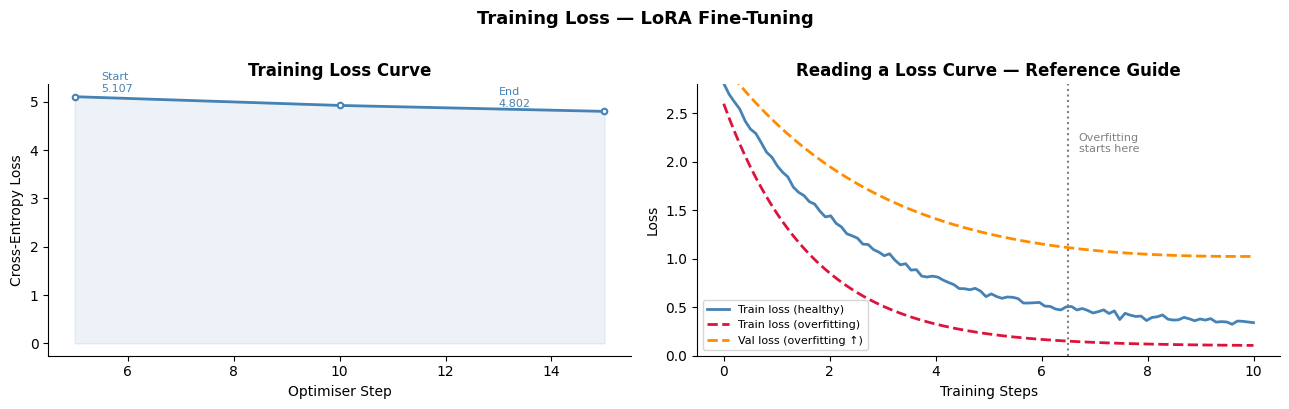

How to read the loss curve:
  ✅ Healthy  : both train and val loss decrease together
  ⚠️  Overfitting: train loss keeps falling, val loss rises
  ⚠️  Underfitting: both losses are high and plateau too early
  ⚠️  Divergence : loss suddenly spikes — LR is too high


In [ ]:
# ── PART 5: VISUALISE TRAINING LOSS ─────────────────────────────────────────
# The loss curve shows whether training is going well.
# A healthy curve: loss decreases smoothly and validation loss tracks train loss.

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Extract logged metrics from trainer history
log_history = trainer.state.log_history

# Separate training and evaluation logs
train_logs = [x for x in log_history if 'loss' in x and 'eval_loss' not in x]
eval_logs  = [x for x in log_history if 'eval_loss' in x]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Chart 1: Training Loss Curve ──────────────────────────────────────────────
if train_logs:
    steps  = [x['step'] for x in train_logs]
    losses = [x['loss'] for x in train_logs]

    axes[0].plot(steps, losses, color='steelblue', linewidth=2,
                 marker='o', markersize=4, markerfacecolor='white',
                 markeredgewidth=1.5)
    axes[0].fill_between(steps, losses, alpha=0.1, color='steelblue')
    axes[0].set_title('Training Loss Curve', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Optimiser Step')
    axes[0].set_ylabel('Cross-Entropy Loss')
    axes[0].spines['top'].set_visible(False)
    axes[0].spines['right'].set_visible(False)

    # Annotate start and end
    axes[0].annotate(f'''Start
{losses[0]:.3f}''', xy=(steps[0], losses[0]),
                     xytext=(steps[0]+0.5, losses[0]+0.1),
                     fontsize=8, color='steelblue')
    axes[0].annotate(f'''End
{losses[-1]:.3f}''', xy=(steps[-1], losses[-1]),
                     xytext=(steps[-1]-2, losses[-1]+0.1),
                     fontsize=8, color='steelblue')

# ── Chart 2: Annotated "What a Good Curve Looks Like" ────────────────────────
x_demo = np.linspace(0, 10, 100)
good   = 2.5 * np.exp(-0.4 * x_demo) + 0.3 + np.random.normal(0, 0.02, 100)
overfit_train = 2.5 * np.exp(-0.6 * x_demo) + 0.1
overfit_val   = 2.5 * np.exp(-0.3 * x_demo) + 0.5 + 0.04 * x_demo

axes[1].plot(x_demo, good,          color='steelblue',  linewidth=2, label='Train loss (healthy)')
axes[1].plot(x_demo, overfit_train, color='crimson',    linewidth=2, linestyle='--',
             label='Train loss (overfitting)')
axes[1].plot(x_demo, overfit_val,   color='darkorange', linewidth=2, linestyle='--',
             label='Val loss (overfitting ↑)')

axes[1].axvline(6.5, color='grey', linestyle=':', linewidth=1.5)
axes[1].text(6.7, 2.1, '''Overfitting
starts here''', fontsize=8, color='grey')

axes[1].set_title('Reading a Loss Curve — Reference Guide',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Training Steps')
axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=8)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].set_ylim(0, 2.8)

plt.suptitle('Training Loss — LoRA Fine-Tuning', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("How to read the loss curve:")
print("  ✅ Healthy  : both train and val loss decrease together")
print("  ⚠️  Overfitting: train loss keeps falling, val loss rises")
print("  ⚠️  Underfitting: both losses are high and plateau too early")
print("  ⚠️  Divergence : loss suddenly spikes — LR is too high")